Primeras filas del dataset:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No

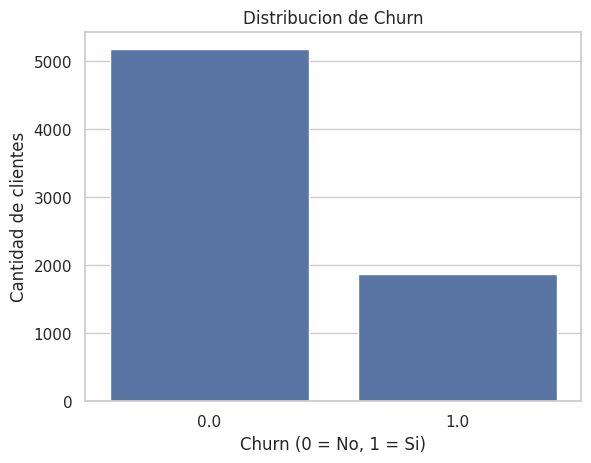


Proporcion de churn (%):
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


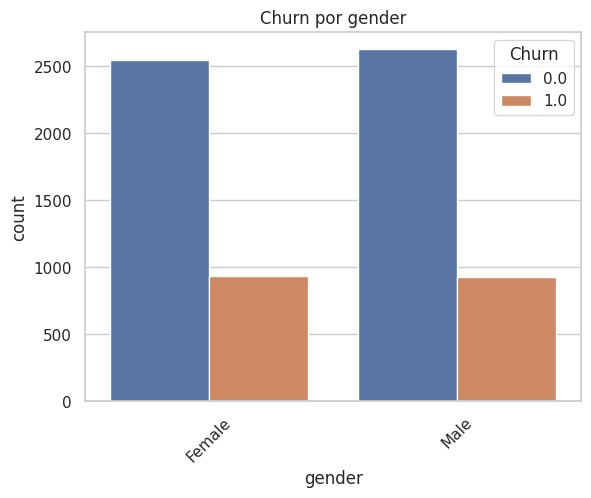

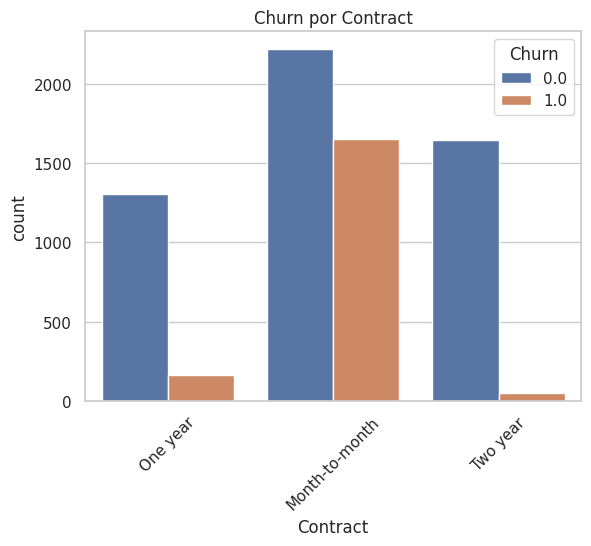

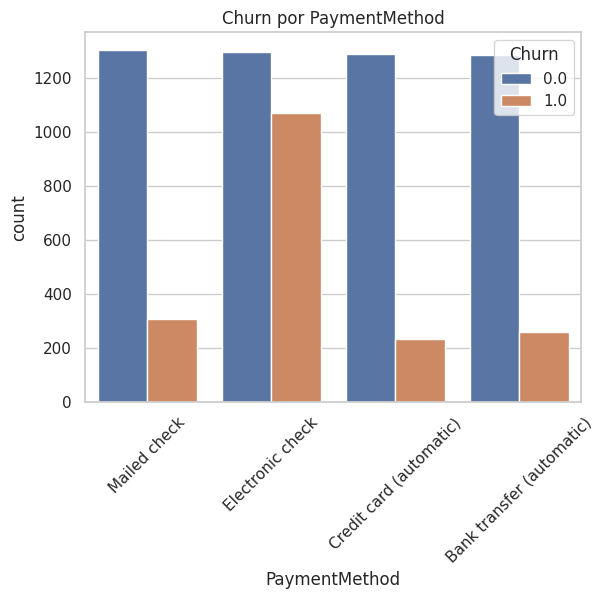

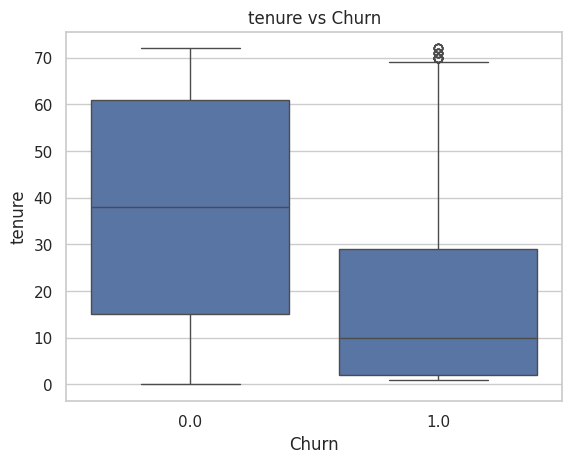


================ INFORME FINAL ================

INTRODUCCION
El objetivo de este analisis es comprender los factores que influyen en la
evasion de clientes (churn) en Telecom X para ayudar a desarrollar estrategias
de retencion de clientes.

LIMPIEZA Y TRATAMIENTO
Se importaron los datos desde un repositorio de GitHub en formato JSON.
Posteriormente se identificaron valores nulos, duplicados y se corrigieron
tipos de datos para variables numericas.

ANALISIS EXPLORATORIO
Se analizaron variables categoricas y numericas relacionadas con la evasion
de clientes mediante graficos de conteo, histogramas y boxplots.

CONCLUSIONES
- Los clientes con contratos mensuales suelen presentar mayor tasa de cancelacion.
- Los cargos mensuales altos pueden asociarse con mayor churn.
- Los clientes con mayor tiempo en la empresa tienden a cancelar menos.

RECOMENDACIONES
- Incentivar contratos de largo plazo.
- Crear estrategias de retencion para clientes nuevos.
- Analizar planes con cargos elevados 

In [3]:
# ================================
# TELECOM X - ANALISIS DE CHURN
# ================================

# 1. IMPORTAR LIBRERIAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ================================
# 2. EXTRACCION DE DATOS
# ================================

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

# Flatten nested JSON columns
def flatten_json_column(df, column_name):
    if column_name in df.columns:
        df = pd.concat([df.drop([column_name], axis=1), df[column_name].apply(pd.Series)], axis=1)
    return df

df = flatten_json_column(df, 'customer')
df = flatten_json_column(df, 'phone')
df = flatten_json_column(df, 'internet')
df = flatten_json_column(df, 'account')
df = flatten_json_column(df, 'Charges') # Flatten the 'Charges' column as well

print("Primeras filas del dataset:")
print(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

# ================================
# 3. EXPLORACION DEL DATASET
# ================================

print("\nColumnas del dataset:")
print(df.columns)

print("\nInformacion general:")
print(df.info())

print("\nEstadisticas descriptivas:")
print(df.describe())

# ================================
# 4. IDENTIFICACION DE PROBLEMAS
# ================================

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores unicos en variables categoricas:")
print(df.select_dtypes(include='object').nunique())

# ================================
# 5. LIMPIEZA Y TRATAMIENTO DE DATOS
# ================================

# eliminar duplicados
df = df.drop_duplicates()

# convertir TotalCharges a numerico si es necesario
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# eliminar valores nulos
df = df.dropna()

# convertir churn a numerico
if "Churn" in df.columns:
    df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

print("\nDataset limpio:")
print(df.head())

# ================================
# 6. ANALISIS DESCRIPTIVO
# ================================

print("\nMedia:")
print(df.mean(numeric_only=True))

print("\nMediana:")
print(df.median(numeric_only=True))

print("\nDesviacion estandar:")
print(df.std(numeric_only=True))

print("\nPromedios agrupados por churn:")
print(df.groupby("Churn").mean(numeric_only=True))

# ================================
# 7. DISTRIBUCION DE EVASION
# ================================

plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Distribucion de Churn")
plt.xlabel("Churn (0 = No, 1 = Si)")
plt.ylabel("Cantidad de clientes")
plt.show()

print("\nProporcion de churn (%):")
print(df["Churn"].value_counts(normalize=True)*100)

# ================================
# 8. EVASION POR VARIABLES CATEGORICAS
# ================================

categorical_cols = ["gender", "Contract", "PaymentMethod"]

for col in categorical_cols:
    if col in df.columns:
        plt.figure()
        sns.countplot(x=col, hue="Churn", data=df)
        plt.title(f"Churn por {col}")
        plt.xticks(rotation=45)
        plt.show()

# ================================
# 9. EVASION POR VARIABLES NUMERICAS
# ================================

numeric_cols = ["MonthlyCharges", "tenure", "TotalCharges"]

for col in numeric_cols:
    if col in df.columns:
        plt.figure()
        sns.boxplot(x="Churn", y=col, data=df)
        plt.title(f"{col} vs Churn")
        plt.show()

# histograma de cargos mensuales
if "MonthlyCharges" in df.columns:
    plt.figure()
    sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)
    plt.title("Distribucion de cargos mensuales")
    plt.show()

# ================================
# 10. INFORME FINAL
# ================================

print("\n================ INFORME FINAL ================")

print("""
INTRODUCCION
El objetivo de este analisis es comprender los factores que influyen en la
evasion de clientes (churn) en Telecom X para ayudar a desarrollar estrategias
de retencion de clientes.

LIMPIEZA Y TRATAMIENTO
Se importaron los datos desde un repositorio de GitHub en formato JSON.
Posteriormente se identificaron valores nulos, duplicados y se corrigieron
tipos de datos para variables numericas.

ANALISIS EXPLORATORIO
Se analizaron variables categoricas y numericas relacionadas con la evasion
de clientes mediante graficos de conteo, histogramas y boxplots.

CONCLUSIONES
- Los clientes con contratos mensuales suelen presentar mayor tasa de cancelacion.
- Los cargos mensuales altos pueden asociarse con mayor churn.
- Los clientes con mayor tiempo en la empresa tienden a cancelar menos.

RECOMENDACIONES
- Incentivar contratos de largo plazo.
- Crear estrategias de retencion para clientes nuevos.
- Analizar planes con cargos elevados para mejorar su valor percibido.
""")